### PGD on CIFAR-10

The principle behind the PGD attack is detailed in the "Tutorial PGD-MNIST.ipynb" notebook. Here, we extend that implementation to the CIFAR-10 dataset using a ResNet-20 architecture to assess the model's robustness against adversarial perturbations.

We load the CIFAR-10 image dataset from torchvision. We download both the training and the tests loads.

In [3]:
from torchvision import datasets
import torchvision.transforms as transforms

transform = transforms.ToTensor() # convert data to torch.FloatTensor

train_data = datasets.CIFAR10(root = 'data', train = True, download = True, transform = transform)
test_data = datasets.CIFAR10(root = 'data', train = False, download = True, transform = transform)

num_train, num_test = len(train_data), len(test_data)
print('number of training data:', num_train, '\n'+'number of test data:', num_test)

number of training data: 50000 
number of test data: 10000


In [4]:
#import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt


We load a pretrained **ResNet-20** model trained on CIFAR-10 via 'torch.hub'. It already performs well and is correctly trained on our dataset, so we can immediately evaluate adversarial robustness. Using a pretrained model ensures a more meaningful adversarial accuracy.

In [5]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using", device)

# Load test dataset (CIFAR10 → 3-channel images)
test_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10(
        root="data",
        train=False,
        download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465),
                                 (0.2023, 0.1994, 0.2010)),
        ])
    ),
    batch_size=1,
    shuffle=True
)

# Load pretrained ResNet-20
model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_resnet20",
    pretrained=True
).to(device)

model.eval()


Using cuda


/usr/local/lib/python3.12/dist-packages/torch/hub.py:335: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt


100%|██████████| 1.09M/1.09M [00:00<00:00, 15.8MB/s]


CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

### PGD Attack

PGD operates by iteratively applying small perturbations to the input image in a way that maximizes the model’s loss function while staying within a specified perturbation budget defined by ϵ.

In [6]:
# PGD Attack
# MNIST init
def pgd_attack(model, images, labels, eps=0.3, alpha=2/255, iters=40) :
    images = images.to(device)
    labels = labels.to(device)
    loss = nn.CrossEntropyLoss()

    ori_images = images.data

    for i in range(iters) :
        images = images.detach()
        images.requires_grad = True
        outputs = model(images)

        model.zero_grad()
        cost = loss(outputs, labels).to(device)
        cost.backward()

        adv_images = images + alpha*images.grad.sign()
        eta = torch.clamp(adv_images - ori_images, min=-eps, max=eps)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach_()

    return images

# restores the tensors to their original scale
mean = [0.491, 0.482, 0.447]
std = [0.202, 0.199, 0.201]
def denorm(batch, mean, std):
    """
    Convert a batch of tensors to their original scale.

    Args:
        batch (torch.Tensor): Batch of normalized tensors.
        mean (torch.Tensor or list): Mean used for normalization.
        std (torch.Tensor or list): Standard deviation used for normalization.

    Returns:
        torch.Tensor: batch of tensors without normalization applied to them.
    """
    if isinstance(mean, list):
        mean = torch.tensor(mean).to(device)
    if isinstance(std, list):
        std = torch.tensor(std).to(device)

    return batch * std.view(1, -1, 1, 1) + mean.view(1, -1, 1, 1)

In [7]:
def test( model, device, test_loader ):

    # Accuracy counter
    correct = 0
    adv_examples = []

    # Loop over all examples in test set
    for data, target in test_loader:

        # Send the data and label to the device
        data, target = data.to(device), target.to(device)

        # Set requires_grad attribute of tensor. Important for Attack
        data.requires_grad = True

        # Forward pass the data through the model
        output = model(data)
        init_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability

        # If the initial prediction is wrong, don't bother attacking, just move on
        if init_pred.item() != target.item():
            continue

        # Calculate the loss
        loss = F.nll_loss(output, target)

        # Zero all existing gradients
        model.zero_grad()

        # Calculate gradients of model in backward pass
        loss.backward()

        # Collect ``datagrad``
        data_grad = data.grad.data

        # Restore the data to its original scale
        data_denorm = denorm(data,mean,std)

        # Call FGSM Attack
        perturbed_data = pgd_attack(model,data_denorm,target,eps=0.3, alpha=2/255, iters=40 )

        # Reapply normalization
        perturbed_data_normalized = transforms.Normalize((0.1307,), (0.3081,))(perturbed_data)

        # Re-classify the perturbed image
        output = model(perturbed_data_normalized)

        # Check for success
        final_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
        if final_pred.item() == target.item():
            correct += 1
            '''# Special case for saving 0 epsilon examples
            if epsilon == 0 and len(adv_examples) < 5:
                adv_ex = perturbed_data.squeeze().detach().cpu().numpy()
                adv_examples.append( (init_pred.item(), final_pred.item(), adv_ex) )'''
        else:
            # Save some adv examples for visualization later
            if len(adv_examples) < 5:
                adv_ex = perturbed_data.squeeze().detach().cpu().numpy()
                adv_examples.append( (init_pred.item(), final_pred.item(), adv_ex) )

    # Calculate final accuracy for this epsilon
    final_acc = correct/float(len(test_loader))
    print(f"Test Accuracy = {correct} / {len(test_loader)} = {final_acc}")

    # Return the accuracy and an adversarial example
    return final_acc, adv_examples

Running the PGD attack on the entire test set is computationally expensive and significantly increases execution time. To speed up the process and facilitate visualization of the results, we chose to operate on a subset of the test loader instead

In [10]:
from torch.utils.data import Subset, DataLoader

# Create a subset of the test loader
subset6000 = Subset(test_data, list(range(6000)))   # indices 0..5999
test_loader6000 = DataLoader(subset6000, batch_size=1, shuffle=False)
acc, ex = test(model, device, test_loader6000)


Test Accuracy = 0 / 6000 = 0.0


The results highlight the strength of the PGD attack: the accuracy of ResNet‑20 falls to 0% when subjected to this adversarial perturbation. This outcome may be partially explained by the deep architecture of ResNet‑20, since models with more layers often exhibit weaker robustness.

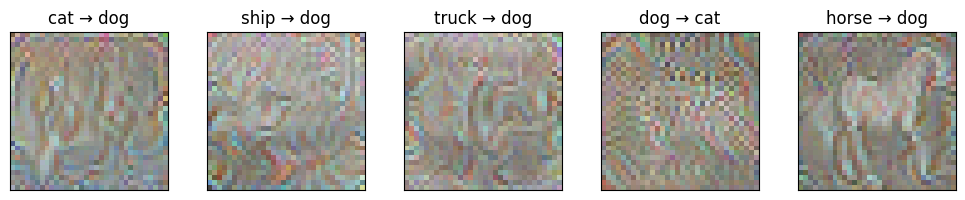

In [14]:
labels=test_data.classes

# ex contient des tuples: (init_pred, final_pred, adv_image)
num_examples = len(ex)
cnt = 1

plt.figure(figsize=(10, 2))

for j in range(num_examples):
    orig_label, adv_label, adv_image = ex[j]  # renommer pour plus de clarté
    plt.subplot(1, num_examples, cnt)
    plt.xticks([])
    plt.yticks([])
    plt.title(f"{labels[orig_label]} \u2192 {labels[adv_label]}")
    # Transpose the image from (channels, height, width) to (height, width, channels)
    plt.imshow(adv_image.transpose((1, 2, 0)))
    cnt += 1

plt.tight_layout()
plt.show()


We can clearly observe that the perturbations introduce noticeable noise patterns across the image.
One limitation of the PGD attack is that the perturbation can become highly visible when the attack parameters, such as the step size α and the perturbation budget ϵ, are not chosen carefully. Because PGD iteratively amplifies the input gradient, overly large steps or a too‑wide perturbation radius can produce noise patterns that are perceptible to the human eye, making the adversarial example unrealistic or easily detectable.